# Part 1. 추천 시스템 기초
## 1. 추천 시스템이란?
사용자의 정보 데이터를 분석, 개인의 취향에 맞는 아이템을 추천하는 알고리즘.
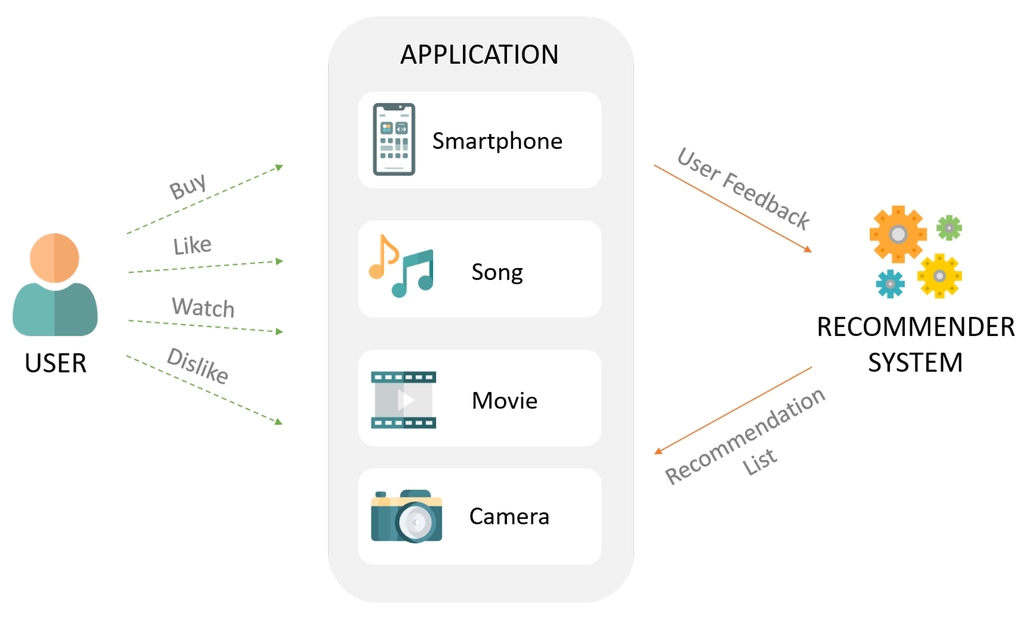

### 1-1. 사용되는 데이터의 종류와 특징
① 명시적 데이터 (Explicit Data)
- 고객들에 의해 입력된 데이터. 사용자가 선호도를 직접적으로 표현한 데이터.
    - Ex) 평점, 좋아요, 투표, 스케일 점수
- 장점 : 취향 정확하게 반영 / 단점 : 데이터 자체를 얻기 힘듦

② 암시적 데이터 (Implicit Data)
- 고객들의 행동을 기반으로 수집된 데이터. 사용자의 선호도가 간접적으로 표현된 데이터.
    - Ex) 조회수, 영상시청 기간, 구매 기록, 페이지 체류 기간
- 장점 : 데이터 얻기 쉬움 / 단점 : 사용자의 취향이나 선호도를 직접적으로 알 수 없음

### 1-2. 추천시스템의 분류
① 내용 기반 필터링 (Content-Based Filtering)
- 콘텐츠의 유사도를 기반으로 사용자에게 추천하는 방법
- 다른 사용자를 고려하지 않고 아이템만 보고 유사한 아이템 추천

② 협업 필터링 (Collaborative Filtering)
- 서비스 내에 있는 다수의 사용자로부터 얻은 선호도 정보를 기반으로 사용자에게 추천하는 방법
1. 사용자 기반(User-Based Filtering) : 유사한 취향의 사용자가 선호한 아이템 추천
2. 아이템 기반(Item-Based Filtering) : 아이템들 간의 선호 패턴을 계산해서 다양한 사용자들의 선호 패턴이 비슷한 아이템을 파악한 후, 그걸 바탕으로 추천

③ 하이브리드 필터링 (Hybrid Filtering)
- 2가지 이상의 다양한 종류의 추천시스템 알고리즘을 조합하여 만들어진 알고리즘


## 2. 내용 기반 필터링 (Content-Based Filtering)
### 2-1. 사용자 프로필
- 추천 시스템에 사용되는 데이터
1. 직접 지정형 : 사용자에게 자신이 선호하는 아이템의 특징을 명시적으로 지정하도록 하는 방법
2. 간접 지정형 : 사용자의 과거 행동 이력에 기반하여 사용자의 프로필을 작성하는 방법
- 사용자의 프로필을 흭득하는 방식
1. 특성 가중치는 사용자가 가지고 있는 아이템 특성 가중치의 평균 값을 활용한다.
2. 사용자의 기호를 따로 파악하거나, 설문조사 또는 자발적인 키워드 입력 등으로 프로필을 획득한다.
3. 아이템에 대한 유저의 기존 평가를 바탕으로 분류(Classification)문제를 해결하는 것과 같다.

→ 좋은 사용자 프로필을 구성할수록, 추천 시스템의 정확도와 만족도가 높아짐.  
→ 다양한 방식(명시적 + 암묵적)을 혼합하여 사용하는 것이 일반적  

### 2-2. 유사도 (Similarity)
1 . 영상, 이미지, 텍스트 등의 형태로 존재하는 아이템 정보 데이터를 벡터화한 이후, 
2. 측정된 유사도를 바탕으로 고객이 선호하는 아이템과 비교하여 유사도가 높은 아이템을 선별
- STEP
1) 인풋 데이터 만들기
    - 아이템 정보 활용
    - 테이블 형태로 데이터 정리  
    -> 숫자로 변환하기 (원-핫 인코딩)
2) 유저 정보 활용
    - 유저의 취향 파악
    - 유저를 n개의 feature로 표현
3) 벡터의 내적과 유사성
    - 벡터 내적 값이 클수록 두 벡터의 유사성이 높음
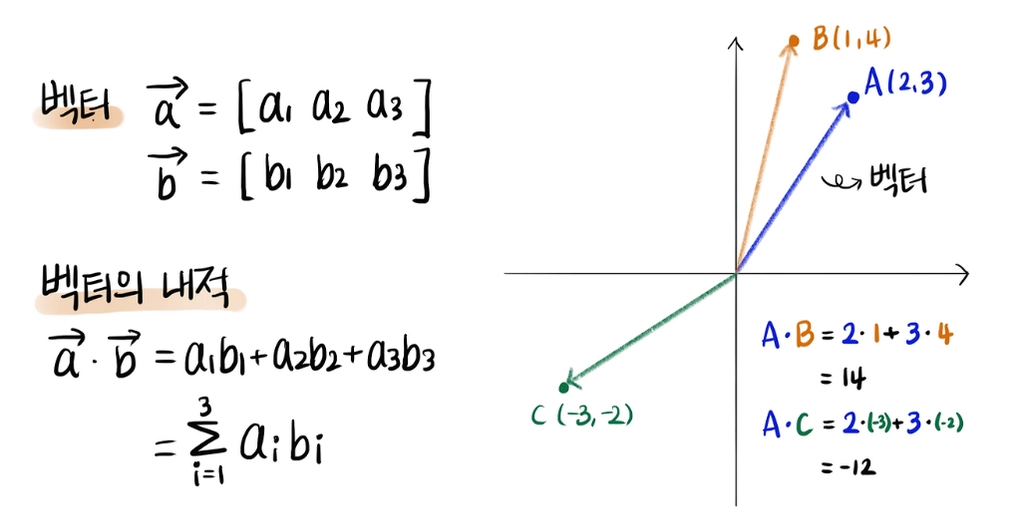

#### TF-IDF(Term Frequency - Inverse Document Frequency)
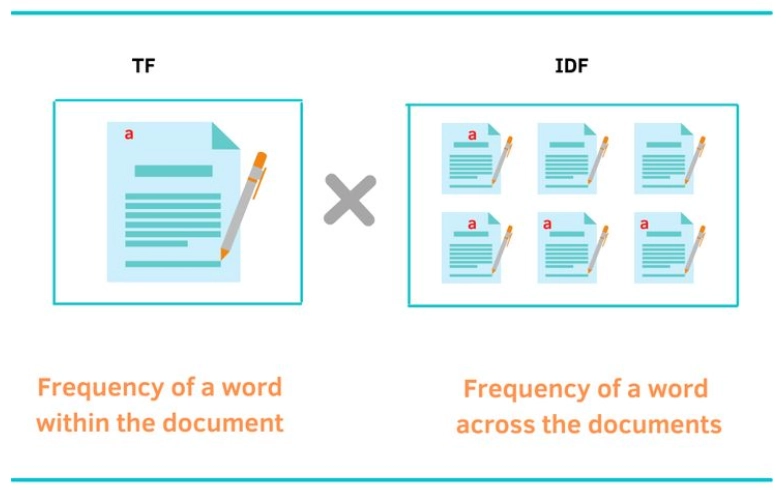  
- 특정 문서 내에 특정 단어가 얼마나 자주 등장하는 지를 의미하는 단어 빈도(TF) 와 
- 전체 문서에서 특정 단어가 얼마나 자주 등장하는지를 의미하는 역문서 빈도(IDF)를 통해서 
- "다른 문서에서는 등장하지 않지만 특정 문서에서만 자주 등장하는 단어"를 찾아서 
문서 내 단어의 가중치를 계산하는 방법
- TF-IDF는 각 단어가 그 문서에서 얼마나 중요한지를 나타내는 값으로, 높을수록 그 단어가 다른 문서들보다 해당 문서에서 더 중요한 역할을 한다는 뜻

### 2-3. 내용 기반 필터링의 장단점
| **장점** | **단점** |
| --- | --- |
| 아이템이 가지고 있는 **feature 자체**에만 집중하기 때문에 다른 유저의 평점 등에 영향을 받지 않음
→ **콜드스타트 문제**에서 자유로움 | item의 feature를 추출해야 하고 이를 통해서 추천
하기 때문에 **정확한 feature를 추출하지 못하면 
정확도가 떨어짐** |
| item의 feature를 통해서 추천을 하기 때문에 추천이 된 이유를 설명하기 용이함 | 기존의 item과 유사한 item 위주로만 추천하기에 
**새로운 장르의 item을 추천하기 어려움** |

## 3. 협업 필터링 (Collaborative Filtering)
- 협업 필터링의 가정 : 과거에 비슷한 선호도를 가진 사용자들은 앞으로도 비슷한 선호도를 가질 가능성이 높다.

### 3-1. 메모리 기반 협업 필터링 (Memory-Based Collaborative Filtering)
- 다른 말로 이웃 기반 협업 필터링 (Neighborhood based Collaborative Filtering)이라고도 함 
- 사용자 또는 아이템 간 유사도를 기반으로 함
- 사용자 A와 비슷한 취향을 가진 사용자가 선호하는 아이템을 추천
- 두 가지 접근법
1. 사용자 기반 : 당신과 비슷한 고객들이 다음 상품도 구매했습니다.
    - 특정 사용자와 타 사용자 간의 유사도
    - 추천하고자 하는 target user와 유사한 사용자들의 평점을 활용
    - 아이템 수 > 사용자 수 : 유리
    - 아이템이 수시로 바뀌는 환경에 적합
    - 뜻밖의 독창적인 아이템 추천 가능
    - 뉴스, 소셜 미디어, 음악 초기 모델에서 활용
2. 아이템 기반 : 이 상품을 선택한 다른 고객들은 다음 상품도 구매했습니다.
    - 사용자들이 그 아이템을 좋아하는지/싫어하는지의 평가 척도가 유사한 아이템을 추천하는 기준이 되는 알고리즘
    - 사용자 수 > 아이템 수 : 유리
    - 아이템 리스트 변화가 적은 환경에 적합
    - 계산이 빠르고 안정적
    - 아마존, 넷플릭스 등이 채택

### 3-2. 메모리 기반 협업 필터링의 한계
1. 희소 행렬 문제
- 주어진 평점/선호도 데이터가 적을 경우, 성능이 저하됨 (Sparsity)
- 유저-아이템 행렬 전체 원소 중 비어있는 원소의 비율이 99.5%를 넘으면, model-based CF 이용

2. 확장성 문제
- 아이템/유저가 계속 늘어날 경우, 확장성이 떨어짐 (Scalability)
- 아이템 i에 대한 평점을 예측하기 위해서는, 아이템 i에 대해 평가를 한 모든 유저와의 유사도를 구해야 함. BUT! 유저가 많아지면? 연산은 계속 늘어나고, 오히려 성능이 떨어지기도 함 -> KNN CF 이용

3. 콜드 스타트 문제
- 협업 필터링은 기존의 평점/행동 데이터를 기반으로 유사도를 계산하는데, 데이터가 아예 없는 경우 추천이 불가능함(신규 유저 or 신규 아이템)
- 해결 방법 : 직접 지정형 프로필 활용, 인구통계학적 정보 활용, 내용 기반 필터링 + 아이템 특성 기반으로 보완

### 3-3. 모델 기반 협업 필터링 (Model-Based Collaborative Filtering)
- 메모리 기반 CF(NBCF)의 한계(Sparsity, Scalability, Cold Start)를 보완하기 위해 등장한 방식으로, 단순히 유사도를 계산하는 것이 아니라, 데이터로부터 패턴을 학습한 모델을 만들어 평점을 예측함
- 즉, 관측된 평점 데이터를 학습(Training) 하여, 관측되지 않은 평점을 예측(Inference) 하는 방식
- Model-based CF는 "데이터 뒤에 숨겨진 패턴(잠재 요인)"을 학습하여 추천의 정확도와 확장성을 동시에 높이는 방식이다.

#### 잠재 요인 (Latent Factor)
사용자와 아이템 사이의 관계를 설명해주는, 눈에 보이지 않는 숨겨진 특성(요인)

#### Factor Model
- 주어진 데이터로는 알 수 없는 사용자-아이템 간의 숨겨진 특성(feature)을 찾기 위해 주어진 Matrix를 사용자-잠재요인 아이템-잠재요인으로 각각 분해하여 학습하는 모델  
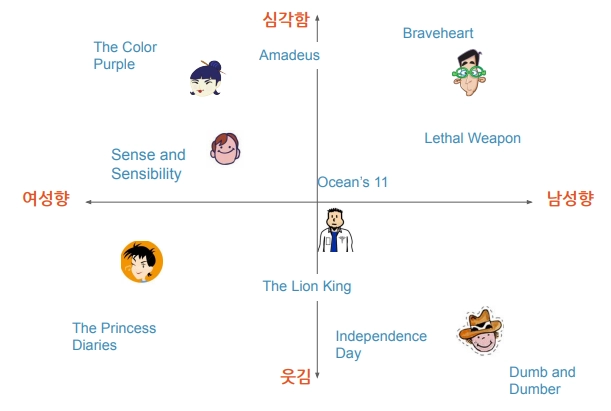  
- 유저와 아이템이 같은 공간에 놓이기 때문에, 서로의 거리나 각도로 유사도 파악 가능

#### latent factor model
- 축(차원)이 무엇을 의미하는지, 몇 개의 차원이 존재하는지 알 수 없음
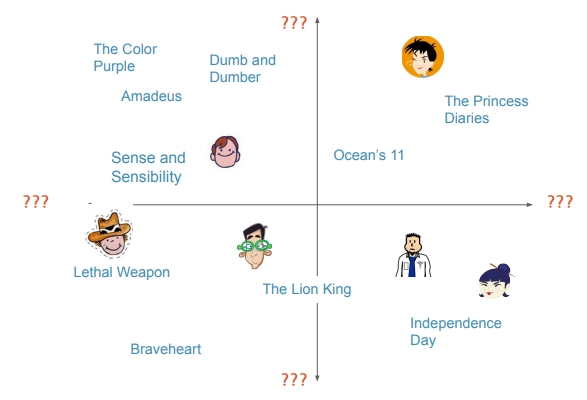

⇒ Latent Factor Model은 사용자와 아이템을 보이지 않는 축(=잠재적인 차원)들을 사용해 나타낼 수 있고, 이를 통해 평점을 예측할 수 있다고 가정하는 모델이다.

#### 행렬 분해 (Matrix Factorization)
- User-Item Matrix (유저-아이템 행렬)에는 유저의 취향+아이템의 특성이 녹아 있지만, 그 결과값만 볼 수 있다.
- 이 행렬을 분해하여 평점을 유저의 잠재 요인과 아이템의 잠재요인의 내적으로 설명할 수 있다면, 이 방법을 통해 평점을 예측할 수 있다.
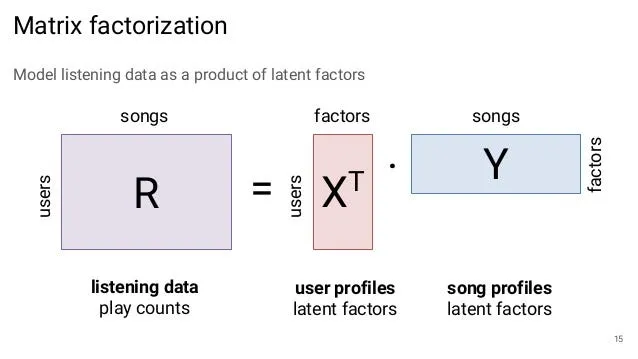
- 입력 행렬: 𝑅(노래/유저)
    - 사용자가 모든 노래를 듣거나 평점 주지 않았을 것이기 때문에, 이 R은 희소 행렬일 가능성이 높다
- 잠재 요인 행렬로 분해: $X^T$ 와 $Y$
    a. $X^T$ 사용자의 잠재 요인 행렬: users(행) x factors(열)
    b. $Y$ 노래(아이템)의 잠재 요인 행렬: factors(행) x songs(열)
- 입력 행렬의 빈칸은 두 잠재 요인 벡터의 내적으로 예측된다!  
    (* 실제로는 예측 평점이 정해진 척도(예: 1~5) 안에 들도록 복잡한 학습 과정과 편향 처리가 추가된다.)

##### MF 수행 방식

| **구분** | **접근 방식** | **특징** |
| --- | --- | --- |
| **SVD** | **수학적 분해 기법** | 행렬 대수학에 기반하여 행렬을 분해합니다. 희소 행렬에는 직접 적용 불가하여 결측치 처리가 필요합니다. |
| **SGD** | **최적화 알고리즘** | 경사 하강법 기반의 알고리즘으로, 관측된 평점에 대해서만 학습을 진행하여 희소성 문제를 우회적으로 해결합니다. |
| **NMF** | **제약 조건 기반 모델** | 분해된 행렬에 비음수(Non-Negative)라는 제약 조건을 추가하여 잠재 요인의 해석력을 높입니다. |
| **PMF** | **확률적 모델** | 평점 예측에 확률 분포를 사용하여 불확실성까지 모델링하는 통계적 접근법입니다. → VAE와 연결 |

여기까지 정리!

> ⇒ 메모리 기반 협업 필터링의 한계를 보완하기 위해, 모델 기반 협업 필터링을 사용한다.

> ⇒ **모델 기반 협업 필터링**은  **행렬 분해**(MF)를 통해 **유저와 아이템의 잠재 요인 벡터**를 만들고, 잠재 요인 벡터 간의 **내적 연산**을 통해 **평점을 예측**한다!

# Part 2. 딥러닝 기반 추천 시스템
## 1. VAE 기반 협업 필터링 (Variational Autoencoder CF)
- 사용자의 아이템 상호작용 벡터(예: 구매/시청 이력)를 입력으로 받아, 잠재 공간에서 재구성하도록 VAE를 학습하는 방식입니다.
- 구조:
    - 인코더: 사용자 이력을 잠재변수 z 분포로 매핑
    - 디코더: z로부터 아이템 분포를 복원  
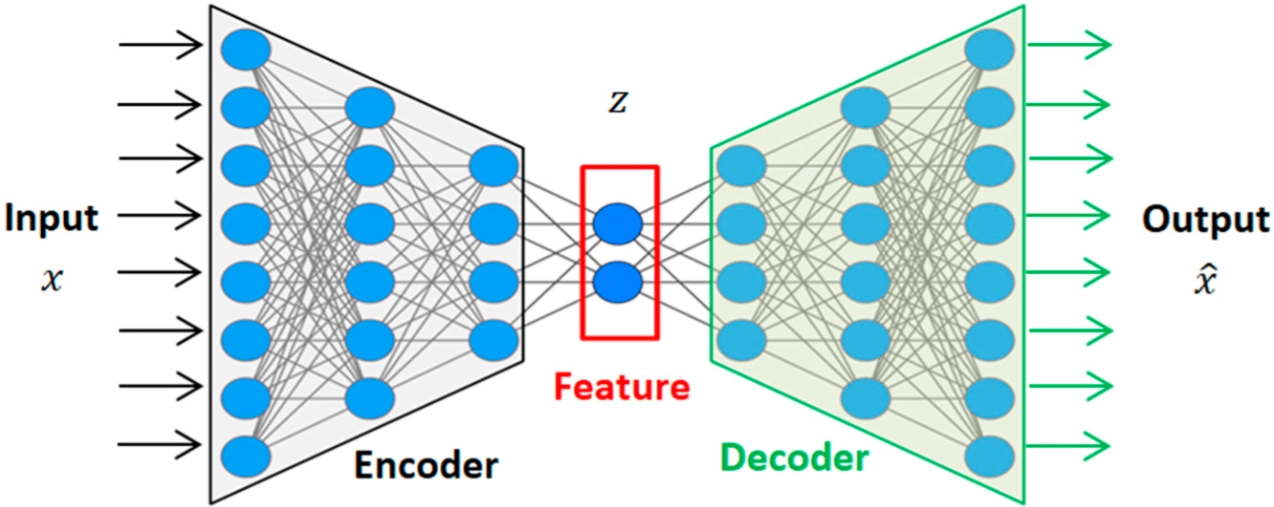  
- 장점:
    - 기존 MF처럼 단일 포인트 벡터가 아니라 확률적 잠재 분포로 사용자 선호를 모델링 하여 불확실성을 반영합니다.
    - 희소한 상호작용 데이터에서도 강건합니다.
- 예시 모델: Mult-VAE

### 1-1. MF의 한계와 딥러닝의 등장
| MF의 근본적 한계 | 내용 | 딥러닝의 해법 |  |
| --- | --- | --- | --- |
| **선형성의 한계** | 평점 예측($\hat{r}_{u, i}$)이 단순한 잠재 벡터의 내적(Dot Product)으로만 이루어집니다. | 비선형 활성화 함수(ReLU 등)를 가진 신경망을 사용하여 복잡한 패턴을 학습합니다. |  |
| **불확실성 무시** | 사용자 취향을 단 하나의 벡터값(Point Estimate)으로만 표현합니다. | **확률 분포**로 취향을 모델링하여 데이터의 불확실성을 반영합니다. |  |

→ 이 한계를 극복하기 위해 등장한 방식 중 하나가 바로 VAE입니다!

### 1-2. 왜 AutoEncoder(AE)가 아닌 VAE(Variational AE)인가?
- AE : 단일값 추정 -> 노이즈에 취약
- VAE : 분포로 추정 -> 취향의 불확실성까지 모델링에 포함시켜 안정성 높음 -> 희소한 데이터에서 더욱 안정적, 일반화 성능 우수

### 1-3. VAE 기반 CF (Mult-VAE)의 작동 구조
- VAE 기반 CF는 사용자의 아이템 상호작용 벡터(𝑥, 예: 구매/시청 이력)를 입력으로 받아, 잠재 공간에서 재구성하도록 학습하는 방식입니다.

| 구성 요소 | 역할 |
| --- | --- |
| **입력** ($x$) | 사용자의 아이템 상호작용 벡터 |
| **인코더** | 사용자 이력을 잠재변수 $z$ 분포로 매핑 |
| **잠재 벡터** ($z$) | 샘플링된 최종 취향 벡터 |
| **디코더** | $z$로부터 아이템 분포를 복원 |

### 1-4. VAE의 비밀 병기: 목적 함수와 KL Divergence
- VAE의 핵심은 목적 함수인 ELBO(Evidence Lower Bound)에 있으며, 이를 통해 두 가지 목표를 동시에 최적화합니다.  
- $\mathcal{L}(x; \theta, \phi) = \underbrace{E_{q_\phi(z|x)} [ \log p_\theta(x|z) ]}_{\text{재구성 오차 최소화 (Reconstruction Loss)}} - \underbrace{D_{\text{KL}}(q_\phi(z|x) || p(z))}_{\text{잠재 공간 정규화 (KL Divergence)}}$  
1.  재구성 오차 최소화 (첫 번째 항):
- 목표: 디코더가 잠재 벡터 $z$를 사용하여 원래 입력 $x$를 최대한 비슷하게 복원하도록 만듭니다. (AE의 역할과 동일)

2.  KL Divergence 항 (두 번째 항):
- 목표: 인코더가 출력하는 잠재 분포 $q(z|x)$가 사전 분포 $p(z)$ (표준 정규 분포)와 유사하도록 강제합니다.
- 역할: 이 항은 모델이 특정 데이터에 과적합하여 잠재 공간을 불규칙하게 만드는 것을 방지하고, 잠재 공간을 넓고 부드럽게(Smooth) 유지하도록 합니다.
- 데이터가 부족한 유저(희소한 데이터)라도 주변의 풍부한 데이터(정보가 많은 유저)로부터 정보를 자연스럽게 연결받아 안정적인 예측을 할 수 있게 됩니다. 이것이 VAE-CF가 희소 데이터에 강한 이유입니다.

- VAE-CF의 주요 장점
1.  확률적 잠재 분포 모델링 (불확실성 반영)
    - 기존 MF처럼 단일 포인트 벡터가 아니라 확률적 잠재 분포로 사용자 선호를 모델링하여, **예측 시의 불확실성을 반영하고 노이즈에 자유로워집니다.**
2.  희소한 상호작용 데이터에서도 살아남음
    - KL Divergence를 통해 잠재 공간을 정규화하여 데이터 연결 능력이 뛰어나며, **희소성 문제에 효과적으로 대응**합니다.
3.  비선형성 학습
    - 신경망 구조를 통해 MF의 한계였던 **복잡하고 비선형적인 패턴을 학습**하여 추천 성능을 극대화합니다.

🔥 이제 딥러닝(VAE)의 비선형성과 확률적 잠재 공간 덕분에, 복잡하고 불확실성이 반영된 사용자-아이템 패턴을 학습하여 희소 데이터에서도 안정적인 추천이 가능해졌습니다.

## 2. GNN 기반 사용자 선호 예측
- VAE 같은 딥러닝 모델도 관계, 순서 같은 정보 활용X -> 관계 자체도 데이터로 활용하는 방법인 GNN 사용

### 2-1. GNN (Graphic Neural Network, 그래프 신경망)
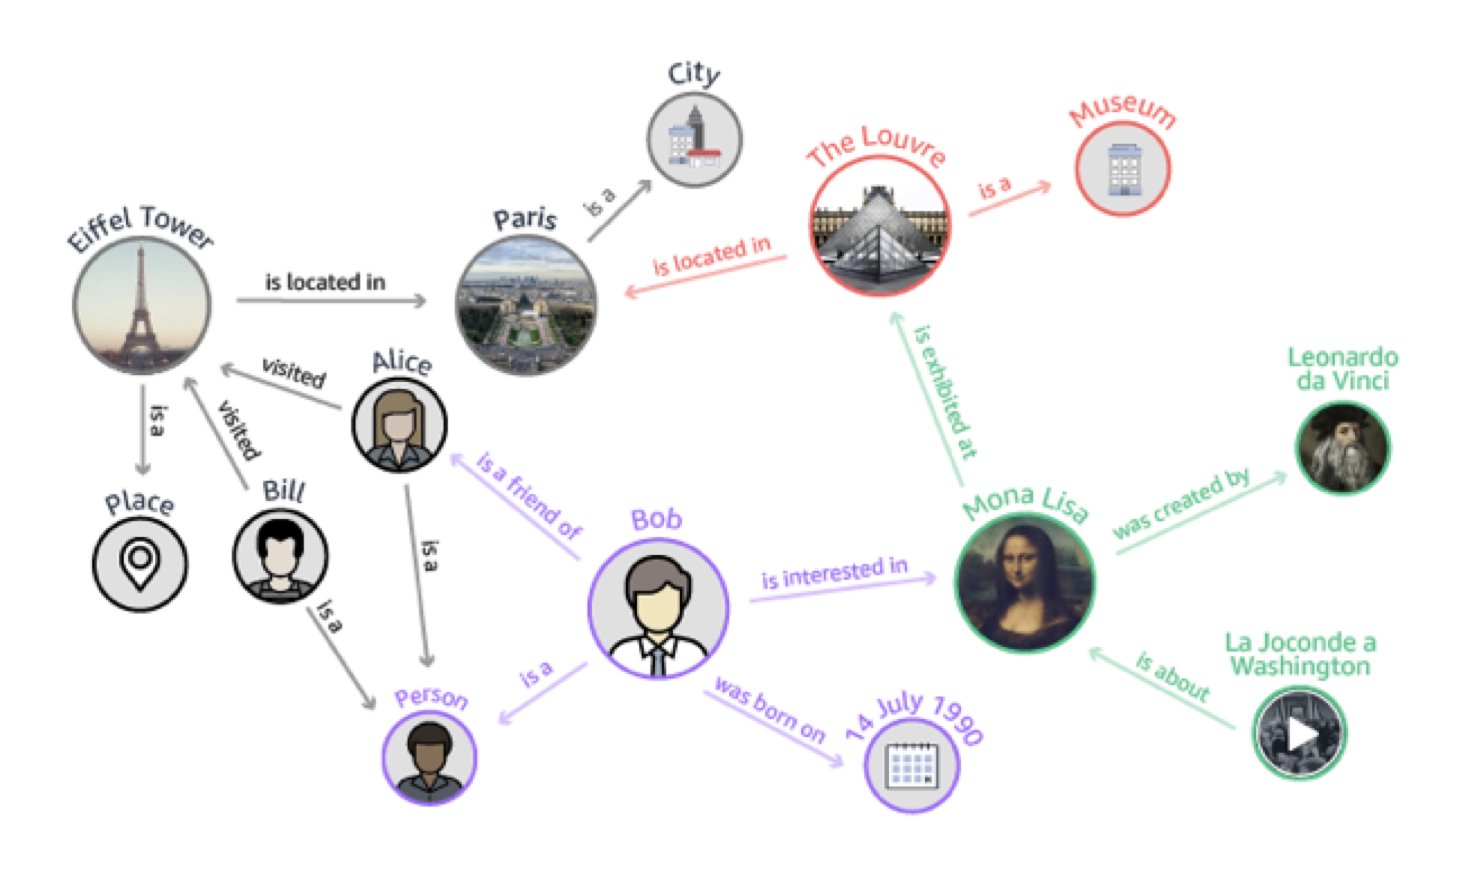  

#### 그래프 (Graph)
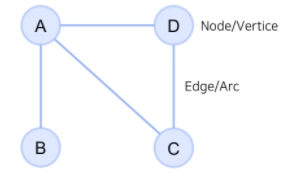
- 노드(Node)와 그 노드를 잇는 선(Edge)을 모아 구성한 자료 구조
- 노드는 현실 세계의 개체를 의미합니다. 엣지는 개체 간 관계나 상호작용을 나타내며, 방향 정보와 가중치를 포함할 수도 있습니다.
- 그래프를 사용하는 이유?
1. 관계, 상호작용과 같이 다소 추상적인 개념을 명시적인 데이터로 구조화
2. 복잡하고 불규칙한 데이터를 모델링하고 학습하도록 하는 방법론

### 2-2. GNN의 구조
- GNN 작동 구조
1. [그래프 구조 생성] 노드는 개별 객체, 엣지는 객체 간 관계나 연결성을 의미함
2. [메시지 패싱] 각 노드가 이웃 노드로부터 정보를 받아 전달
    1) [메시지 생성] 이웃 노드로에 전달할 메시지 생성
    2) [집계] 받은 여러 이웃의 메시지를 하나로 합침 
    3) [갱신] 자신의 노드 상태를 업데이트함
3. [최종 출력]
- GNN 핵심 아이디어  
    - 내 이웃 노드(나와 비슷한 사용자, 내가 본 아이템)의 정보를 나에게 전달/요약(Message Passing)

### 2-3. GNN의 프로세스
- GNN은 그래프를 입력 받아 메시지 패싱(Message Passing)을 수행합니다. 이때, 각 노드는 자신의 이웃 노드들의 정보(잠재 요인)를 수집하여 자신의 은닉 상태(임베딩)를 업데이트합니다.
- 이 과정을 K번 반복하여 더 멀리 있는 이웃의 정보까지 반영합니다. 이를 통해 이웃들의 취향까지 반영한 최종 임베딩을 얻고, 두 노드 간 선호도를 예측할 수 있습니다.

#### 각 단계 상세 설명
1. 그래프 구조 생성
- GNN에서는 노드와 엣지를 정의한 후, 각각의 피처를 담아 표현하는 것이 첫 번째 단계입니다.
2. 메시지 패싱 (Message Pasing)
- 메시지 패싱: 그래프에서 노드 간 정보를 전달하고 상호작용하는 방법
- 보통 하나의 GNN 레이어에서 ‘메시지 생성 - 집계 - 갱신’ 의 세 단계로 이루어집니다. 그리고 GNN 모델이 k개의 레이어로 구성되어 있다면, k번의 (생성-집계-갱신) 과정이 반복됩니다.

💡 메시지 패싱 단계 정리

**[1단계] 타겟 노드 선정**
- 타겟 노드 : 정보를 갱신하려는 노드로, 모든 노드가 한 번씩 돌아가면서 타겟 노드가 됨
- *지금부터 $v$ 노드를 갱신하자!*

**[2단계] 메시지 생성**
- *이웃에 전달할 메시지를 생성하자*

**[3단계] 메시지 집계**
- *$v$의 이웃 노드들의 임베딩을 요약본으로 만들자. 이때, 평균을 내서 요약해야지.*

**[4단계] 갱신**
- *$v$ 노드의 원래 임베딩과 집계 결과를 합쳐서 새 정보를 만들어서 갱신 완료*

### 2-4. LightGCN (Light Graph Convolutional Networks)
- 주요 GNN 아키텍처
1. GCN (Graph Convolutional Network) : 그래프 위에서 **Convolution 연산** 수행. 이웃 노드와 타겟 노드에 동일한 파라미터 적용함.
2. GRN (Graph Recurrent Network) : RNN + GNN 결합. **시간에 따라 노드 특성이 업데이트** 되어 그래프의 동적 변화 포착 가능. 
3. GAT (Graph Attention Network) : 이웃 노드 간 중요도를 학습해 가중 평균. **타겟 노드의 이웃 노드 중 중요한 노드에 가중치**를 둠.
4. GraphSAGE : 대규모 그래프에 대해 **샘플링 기반으로 학습**. 이웃 노드와 타겟 노드의 가중치 값을 더하지 않고, concat함.

#### LightGCN
- GCN의 한 종류이며, 더 크게는 GNN의 한 종류입니다.
- 그 중에서도 추천 시스템에 특화된 GNN으로, 복잡성을 제거하고 최적화한 버전입니다.
- LightGCN에서는 GNN의 구성 요소 2가지를 제거했습니다.
1. 특징 변환(Feature Transformation) 제거
2. 비선형 활성화 함수 (Non-linear Activation) 제거

⇒ LightGCN은 오직 정규화된(Normalized) 이웃 임베딩의 합(Aggregation)만으로 구성되는데요. CF의 본질에 충실하게 ‘그래프 구조’와 ’전파’라는 뼈대만 남긴, 매우 가볍고 효율이 좋은 모델입니다. 

## 2-5. GNN 활용 사례
1. [SNS] Pinterest 
- Pinterest는 GNN을 활용하는 서비스의 대표적인 성공 사례인데요. 약 30억 개의 노드와 180억 개의 엣지로 구성된 그래프 속에서 사용자들이 상호작용하는 핀, 보드, 카테고리를 분석해 추천합니다.
2. [핀테크] 사기 및 자금 세탁 방지
- GNN은 ‘돈이 어디서 어디로 흘러가는가’라는 송금 네트워크 자체를 분석 -> 금융 사기와 자금 세탁 탐지를 더 쉽게 만들었습니다.
3. [B2C 비즈니스] 우버 이츠 메뉴 추천
- 우버 이츠는 GraphSAGE라는 GNN 기반 알고리즘을 도입해 추천 시스템을 고도화했습니다.

## 2-6. GNN의 장단점
- 장점
1. 고차원 협업 시그널 (High-order Collaborative Signals) 포착 : 취향 비슷한 사용자들의 아이템 정보 반영
2. 정형화되지 않은 데이터 학습 가능 : 각 노드가 정형화된 데이터로 정의되지 않음
3. Cold Start 문제 완화에 효과적 : 노드의 고유 특징과 주변 이웃과의 관계 활용
- 단점
1. 과평탄화 (Over-smoothing) 문제 : 모든 노드의 임베딩이 같은 값으로 수렴
2. 과압축 (Oversquashing) 문제 : 벡터 하나에 압축하려다 정보 손실
3. 계산 복잡도 ↑ : 수십억 개의 노드와 엣지
4. 해석의 어려움(순서 반영X)

# 3. Transformer 기반 추천 시스템
- 순서와 문맥으로 사용자를 이해하다

## 3-1. 기존 추천 시스템의 순차적 한계
### 1.1 CF의 순차적 한계
- 구매, 클릭 순서 고려 X, 구매 시기(방금, 1년 전 등) 고려 X, 사용자의 다음 행동 예측 X, 일반적인 선호도 찾음 O


### 1.2 GNN의 순차적 한계
- RNN과 같이 장기의존성 문제를 지닙니다.
- 메시지 패싱 과정을 반복하면서 정보가 희석됨  

🔴 CF와 GNN은 사용자의 일반적인 선호도, 관계를 파악하는 데 뛰어나지만, 행동의 ‘순서’와 ‘문맥’, 특히 동적인 의도를 파악하는 데 한계가 있었습니다.  

🟢 따라서 사용자의 행동 시퀀스를 이해하고 다음 행동을 예측하는 **Transformer** 모델이 대안으로 등장하였습니다.  


## 3-2. Transformer: 사용자 행동을 순서(Sequence)로 접근
- Transformer는 시퀀스 내의 문맥과 핵심 의도를 파악하는 데 강력합니다.
1. 동일 아이템이어도 문맥에 따라 의미가 달라짐
- 등산화 : 캠핑 준비 vs 겨울 출퇴근 준비
2. 시간 순서를 뛰어넘어 핵심 의도 포착
- 토너 검색 -> 아주 예전에 샀던 프린터와 강한 관계

⇒ 이처럼 Transformer는 시간 순서나 거리에 얽매이지 않고, 전체 시퀀스 내에서 현재 의도와 가장 관련성이 높은 핵심 문맥을 정확히 '주목'하여 예측합니다.

## 3-3. Transformer 기반 주요 추천 시스템 모델
### SASRec
- 단방향 어텐션으로 과거 정보만 활용하여 미래 행동을 추측하는 방식으로 훈련을 받은 추천 시스템 모델입니다 ​
- **문제점 :**
    - **계산량 많음 :** 각 타임 step 에 따른 loss 모두 계산 (하나의 시퀀스에서 t-1 번 loss 계산)
    - **단방향성 :** 이전에 등장한 값만 참고할 수 있고 미래의 값은 참고할 수 없음

**→ 이 두가지 문제점을 보완해서 등장한 알고리즘이 - BERT4rec**

### BERT4Rec
- 양방향 어텐션으로 과거 정보와 미래 정보를 활용하여 예측하는 방법을 훈련한 모델입니다.
- 방식: 양방향(Bi-directional) 어텐션 (BERT와 유사)
- 어텐션 계산: 시퀀스의 일부를 [MASK] 토큰으로 일부러 가리고, 가려진 아이템이 '과거와 미래의 모든 아이템'을 참조할 수 있습니다.
- 목표: 시퀀스 내 가려진 아이템 예측 (Masked-item prediction)
- 특징:
    - 아이템의 양방향 문맥(과거와 미래)을 모두 고려합니다.
    - 학습 과정에서 시퀀스 전체의 선호도를 파악하는 데 더 초점이 맞춰져 있습니다.

#### SASRec vs. BERT4Rec
- 학습 방식의 차이
    - SASRec: 단방향 어텐션 → 최대한 현실과 유사한 방식으로 과거 데이터만 보고 학습
    - BERT4Rec: 양방향 어텐션 → 아이템 간의 숨겨진 복잡한 맥락을 훨씬 더 깊고 풍부하게 학습
- 학습 환경과 다르더라도 더욱 풍부한 맥락을 이해하고 있는 BERT4Rec이 일반적으로 더욱 좋은 성능을 보인다고 합니다.

# 4. 제언: 오늘날의 추천 시스템
## 4-1. LLM의 시대
- 관점의 전환 : 추천을 랭킹 문제가 아닌 언어 문제로 푼다
- 과거 : 추천 시 점수 출력 -> LLM : 추천 시 문장 출력 (추천이유까지 알려줌)
- 대화형 추천(자연어 요청 이해 및 추천) 가능
- Zero-shot 추천 가능(텍스트 설명만으로)

### P5 / TALLRec
- P5 : 모든 추천 과제(랭킹, 다음 아이템 예측, 설명 생성 등)를 LLM이 풀 수 있도록 '하나의 거대한 텍스트 프롬프트' 문제로 통일시킨 모델
- 기존 추천 시스템은 모든 정보를 벡터로 임베딩 한 뒤, 숫자 간 거리를 계산하는 방식이었으나 P5는 이 과정을 모두 없애고 순수하게 텍스트만으로 추천을 수행합니다.
- (-) 엄청난 컴퓨팅 자원과 시간이 소모
- TALLRec : P5처럼 처음부터 다 학습시키긴 비싸니까, 이미 잘 만들어진 범용 LLM(e.g., LLaMA)을 추천 작업에 맞게 효율적으로 튜닝(Tuning)하는 프레임워크
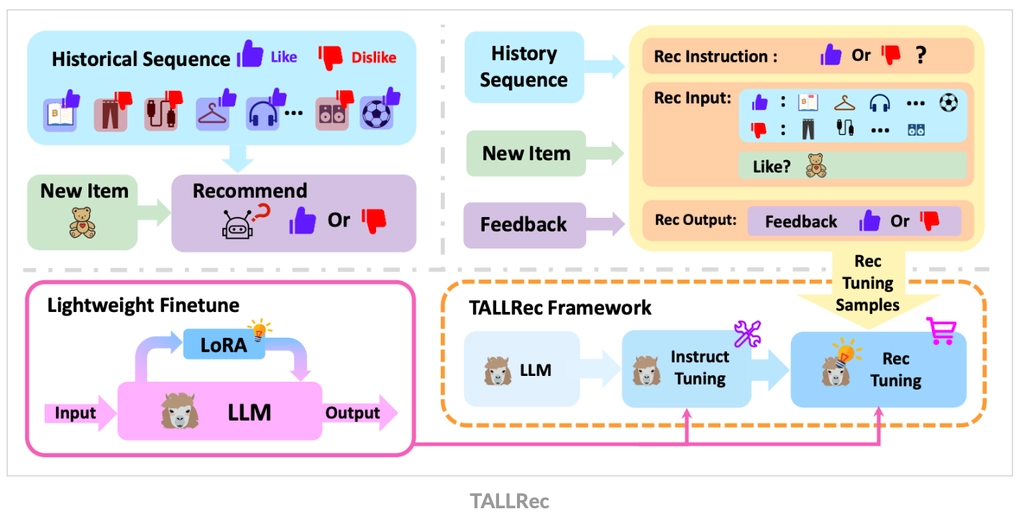


⇒ LLM은 단순한 성능 향상이 아니라, 추천 시스템이 사용자와 상호작용하는 방식 자체를 근본적으로 바꾸고 있습니다.

## 

## 4-2. 인기 편향과 XAI 문제
1. 인기 편향은 추천 시스템이 소수의 인기 아이템을 과도하게 노출하는 반면, 다수의 비인기 아이템이 받아야 할 관심을 받지 못하는 현상
- 현실 데이터는 “인기 아이템”에 불균형하게 집중되어 있음
- 모델이 학습하면서 이 편향을 강화함 → “Rich-get-richer” 현상
- 결과적으로 비인기 아이템은 거의 추천되지 않음

⇒ 비인기/신규 아이템은 노출 기회조차 얻지 못하고, 사용자는 새로운 발견의 즐거움을 잃게됨

2. 설명가능성(XAI)
- 이걸 왜 추천했는지 설명할 수 있는가?
- 문제: GNN, Transformer 같은 딥러닝 모델은 강력하지만 블랙박스 문제가 있음
- 필요성: "왜 이걸 나에게 추천했는지" 고객을 설득해야 하고, 비즈니스 담당자에게 추천의 근거를 제시해야 함.

## 4-3. 컴퓨팅 자본, 콜드 스타트 문제를 고려한 추천시스템 도입
- 비용 문제: 딥러닝은 전면 도입하기엔 너무 비쌈 
- 따라서,  여전히 현업에서는 선형 기반 추천 시스템과 병행되고 있습니다. ex) 유튜브, 아마존 등

1단계 : 후보군 생성

- 목표 : 수백만, 수천만 개의 전체 아이템 중에서 사용자가 조금이라도 좋아할 만한 - 아이템 수백 개를 매우 빠르게 골라냄
사용 모델 : 선형 모델 (내용 기반 필터링, 협업 필터링, 행렬 분해)

2단계 : 순위 매기기
- 목표 : 1단계에서 추려진 수백 개의 후보군을 대상으로 사용자가 가장 좋아할 순서대로 매우 정교하게 순위를 매김
- 사용 모델 : 딥러닝 모델 (GNN, Transformer, VAE)